# Toronto Condo Rental Analysis

**A reproducible analysis of Toronto condo asking rents from rendered public
listing pages**

| Snapshot | Collection scope | Raw unique listings | Analysis-ready |
| --- | ---: | ---: | ---: |
| 2026-07-25 | 10 result pages | 492 | 490 |

This notebook presents the portfolio-facing analysis layer of the project.
Scraping, cleaning, validation, and chart generation are implemented as
reusable Python modules under `src/`; this notebook focuses on decisions,
evidence, and interpretation.

## Executive summary

- The median monthly asking rent was **$2,550 CAD**; the middle 50% ranged from
  **$2,250 to $3,088**.
- Median asking rent increased across the well-represented room categories:
  **$1,925 for studios**, **$2,288 for one-bedroom units**, and **$2,980 for
  two-bedroom units**.
- Listings reporting one parking space had a **$2,750 median**, compared with
  **$2,400** for listings reporting none. This is descriptive, not a causal
  parking premium, because unit size and room mix also differ.
- Among listings with closed size ranges, approximate size and asking rent had
  a **moderate positive relationship** (Pearson correlation **0.45** after
  excluding IQR price flags).

These findings describe one active-listing snapshot and should not be read as
contracted rents or a complete census of the Toronto rental market.

## Questions and analytical workflow

The analysis addresses four practical questions:

1. What does the distribution of current asking rents look like?
2. How does rent vary by room configuration?
3. How does reported parking availability relate to asking rent?
4. What relationship is visible between approximate unit size and rent?

```text
Rendered listing pages
        ↓
Raw timestamped CSV
        ↓
Schema checks, scope exclusions, deduplication, quality flags
        ↓
Analysis-ready CSV
        ↓
Reusable summaries and publication-ready charts
```

The scraper respects verification challenges rather than automating around
them. Data collection should always be performed in accordance with the source
site's terms, robots guidance, and reasonable request limits.

## 1. Reproducible setup

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.analyze import (
    build_overview,
    load_analysis_data,
    summarize_by_parking,
    summarize_by_room,
)

PROCESSED_DIR = ROOT / "data" / "processed"
CHART_DIR = ROOT / "outputs" / "charts"

clean_files = sorted(PROCESSED_DIR.glob("toronto_condos_*_clean.csv"))
if not clean_files:
    raise FileNotFoundError(
        "No cleaned CSV found. Run src/scraper.py and src/clean_data.py first."
    )

DATA_PATH = clean_files[-1]
print(f"Analysis dataset: {DATA_PATH.relative_to(ROOT)}")

Analysis dataset: data/processed/toronto_condos_20260725_193901_clean.csv

In [2]:
df = load_analysis_data(DATA_PATH)
overview = build_overview(df)
room_summary = summarize_by_room(df)
parking_summary = summarize_by_parking(df)

print(f"Loaded {len(df):,} analysis-ready listings.")
print(
    "Observed collection window (UTC): "
    f"{df['ScrapedAtUTC'].min()} to {df['ScrapedAtUTC'].max()}"
)

Loaded 490 analysis-ready listings.
Observed collection window (UTC): 2026-07-25 23:37:49.976313+00:00 to 2026-07-25 23:39:00.683983+00:00

## 2. Data quality and analytical scope

Two records were excluded because they represented room-only or lower-level
accommodation rather than whole-condo listings. Open-ended size bands such as
`0–499 sqft` remain valid rental observations but are not assigned an artificial
midpoint. High-price records are retained and flagged instead of silently
deleted.

In [3]:
excluded_files = sorted(PROCESSED_DIR.glob("*_excluded.csv"))
excluded_count = (
    len(pd.read_csv(excluded_files[-1])) if excluded_files else 0
)

quality_summary = pd.DataFrame(
    {
        "Stage / flag": [
            "Unique scraped listings",
            "Excluded by scope rules",
            "Analysis-ready listings",
            "Closed size ranges",
            "Open-ended size ranges",
            "IQR price flags",
        ],
        "Count": [
            len(df) + excluded_count,
            excluded_count,
            len(df),
            int(df["AnalysisSizeSqft"].notna().sum()),
            int(df["OpenEndedSizeRange"].sum()),
            int(df["PriceOutlierIQR"].sum()),
        ],
        "Treatment": [
            "Starting sample",
            "Removed from analysis",
            "Retained",
            "Used for size analysis",
            "Retained; omitted from size analysis",
            "Retained and visibly flagged",
        ],
    }
)
display(quality_summary)

Stage / flag,Count,Treatment
Unique scraped listings,492,Starting sample
Excluded by scope rules,2,Removed from analysis
Analysis-ready listings,490,Retained
Closed size ranges,407,Used for size analysis
Open-ended size ranges,83,Retained; omitted from size analysis
IQR price flags,22,Retained and visibly flagged


## 3. Headline market snapshot

In [4]:
overview_values = overview.set_index("Metric")["Value"]
overview_display = pd.DataFrame(
    {
        "Metric": [
            "Analysis-ready listings",
            "Median monthly asking rent",
            "Middle 50% of asking rents",
            "Median approximate size",
            "Median asking rent per sqft",
        ],
        "Value": [
            f"{int(overview_values['Listings']):,}",
            f"${overview_values['MedianRentCAD']:,.0f}",
            (
                f"${overview_values['RentQ1CAD']:,.0f} – "
                f"${overview_values['RentQ3CAD']:,.0f}"
            ),
            f"{overview_values['MedianAnalysisSizeSqft']:,.1f} sqft",
            f"${overview_values['MedianPricePerSqftCAD']:,.2f}",
        ],
    }
)
display(overview_display)

Metric,Value
Analysis-ready listings,490
Median monthly asking rent,"$2,550"
Middle 50% of asking rents,"$2,250 – $3,088"
Median approximate size,649.5 sqft
Median asking rent per sqft,$3.91


### Rent distribution

The distribution is right-skewed. A small number of high-price listings pull
the mean above the median, so the median and interquartile range are more
representative of the typical listing in this snapshot.

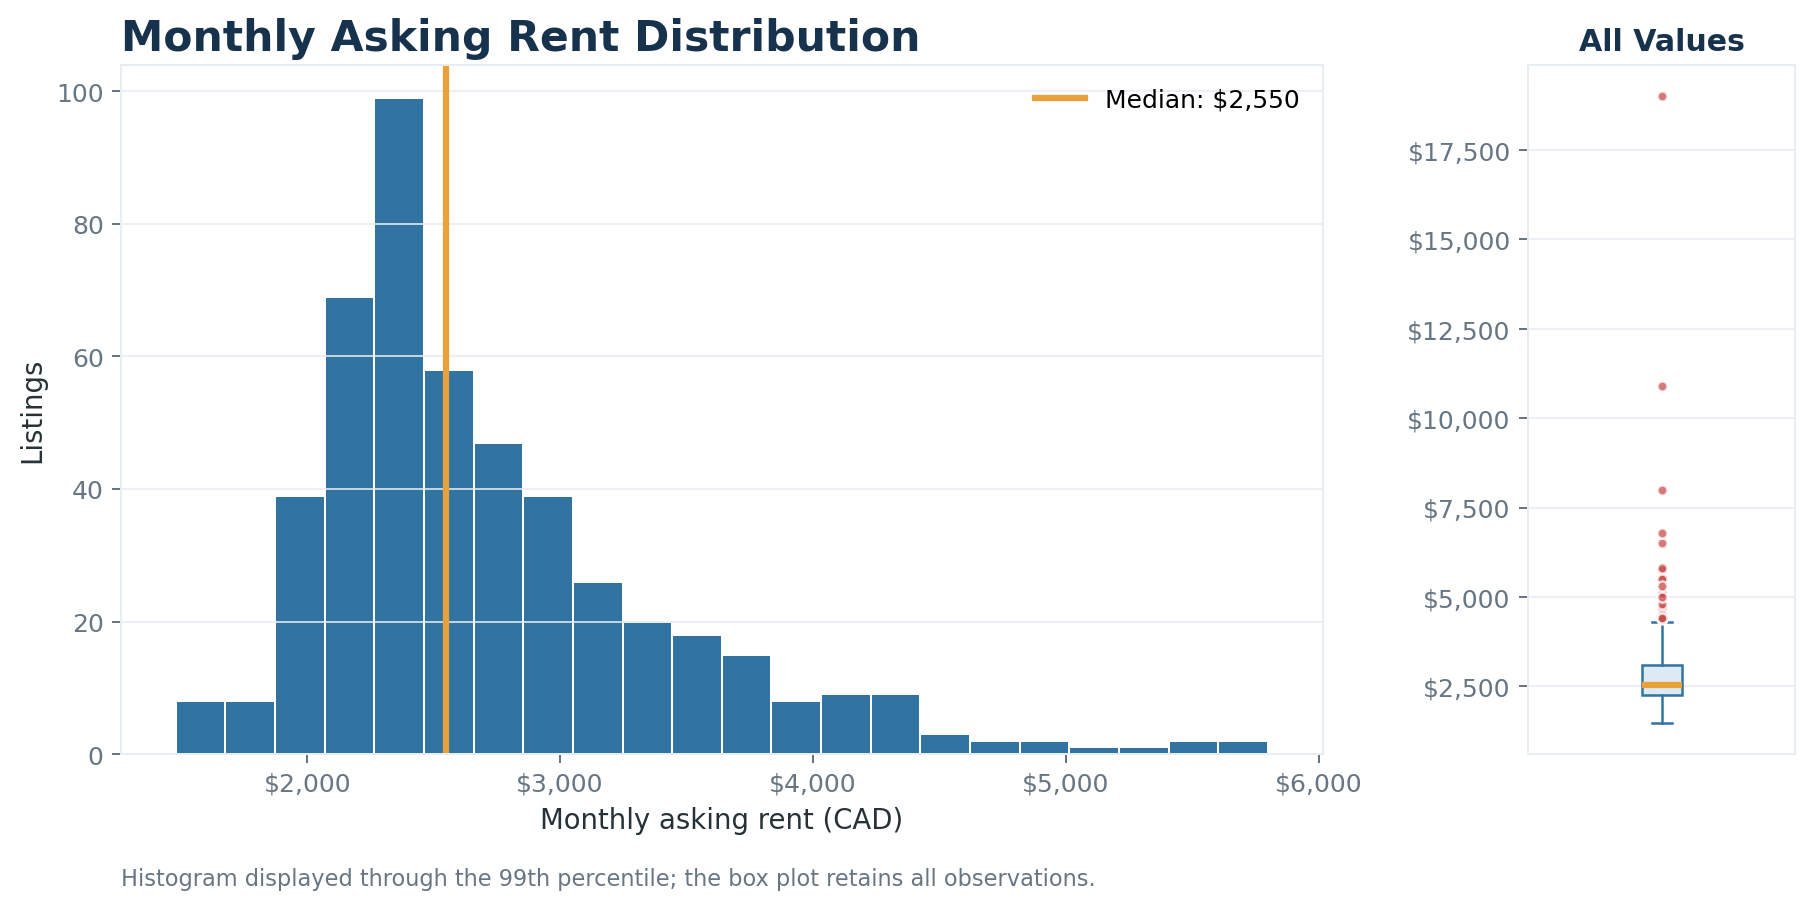

In [5]:
display(Image(filename=CHART_DIR / "rent_distribution.png"))

## 4. Room configuration

The table and chart display room groups with at least five observations.
Smaller categories remain in the exported summary table but are omitted from
the comparison chart to avoid over-interpreting very small samples.

Room,Listings,Median rent,Q1 rent,Q3 rent
Studio,33,"$1,925","$1,850","$2,050"
1,146,"$2,288","$2,150","$2,400"
1+1,108,"$2,474","$2,350","$2,700"
2,127,"$2,980","$2,700","$3,300"
2+1,37,"$3,450","$3,200","$3,800"
3,31,"$3,600","$3,199","$4,200"


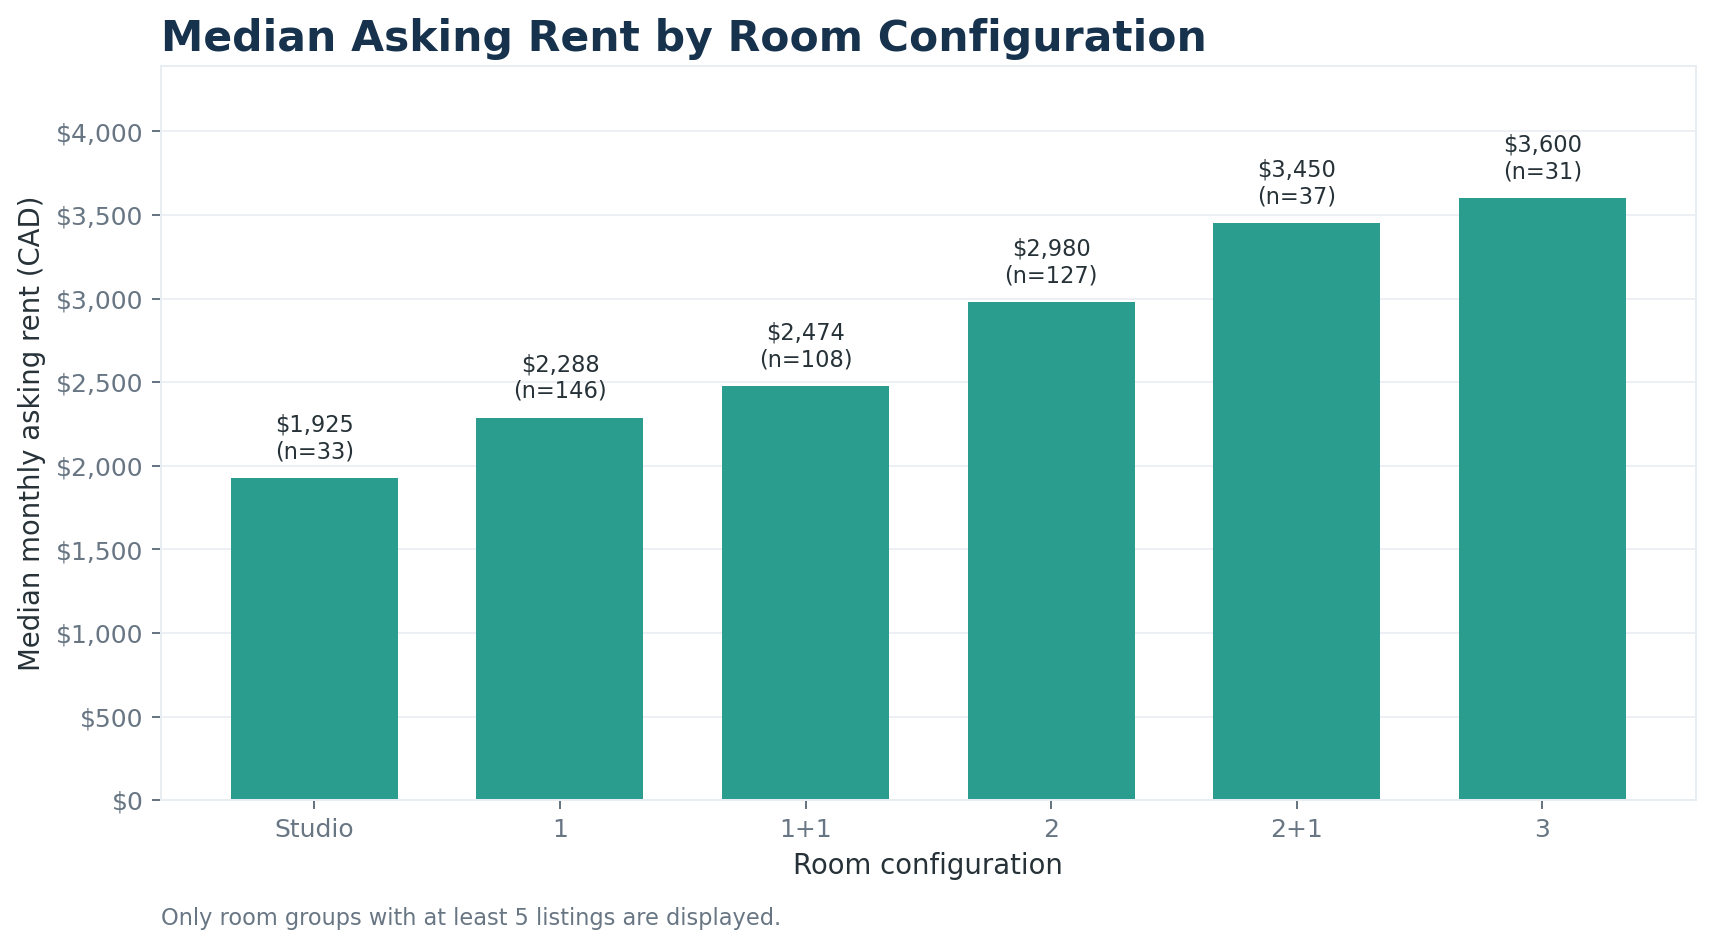

In [6]:
room_display = room_summary.loc[
    room_summary["Listings"].ge(5),
    ["Room", "Listings", "MedianRentCAD", "RentQ1CAD", "RentQ3CAD"],
].copy()
room_display.columns = [
    "Room", "Listings", "Median rent", "Q1 rent", "Q3 rent"
]
for column in ["Median rent", "Q1 rent", "Q3 rent"]:
    room_display[column] = room_display[column].map(
        lambda value: f"${value:,.0f}"
    )

display(room_display)
display(Image(filename=CHART_DIR / "median_rent_by_room.png"))

**Interpretation.** The median rises from $1,925 for studios to
$2,288 for one-bedroom units, $2,475 for one-bedroom-plus-den units, and
$2,980 for two-bedroom units. This is an unadjusted category comparison;
location, unit size, building quality, and amenities remain potential
confounders.

## 5. Parking availability

Parking is parsed as the number of reported spaces. Groups with fewer than five
listings are excluded from the chart but retained in the underlying table.

Parking spaces,Listings,Median rent,Q1 rent,Q3 rent
0,234,"$2,400","$2,150","$2,700"
1,244,"$2,750","$2,350","$3,400"
2,11,"$3,495","$3,125","$4,800"


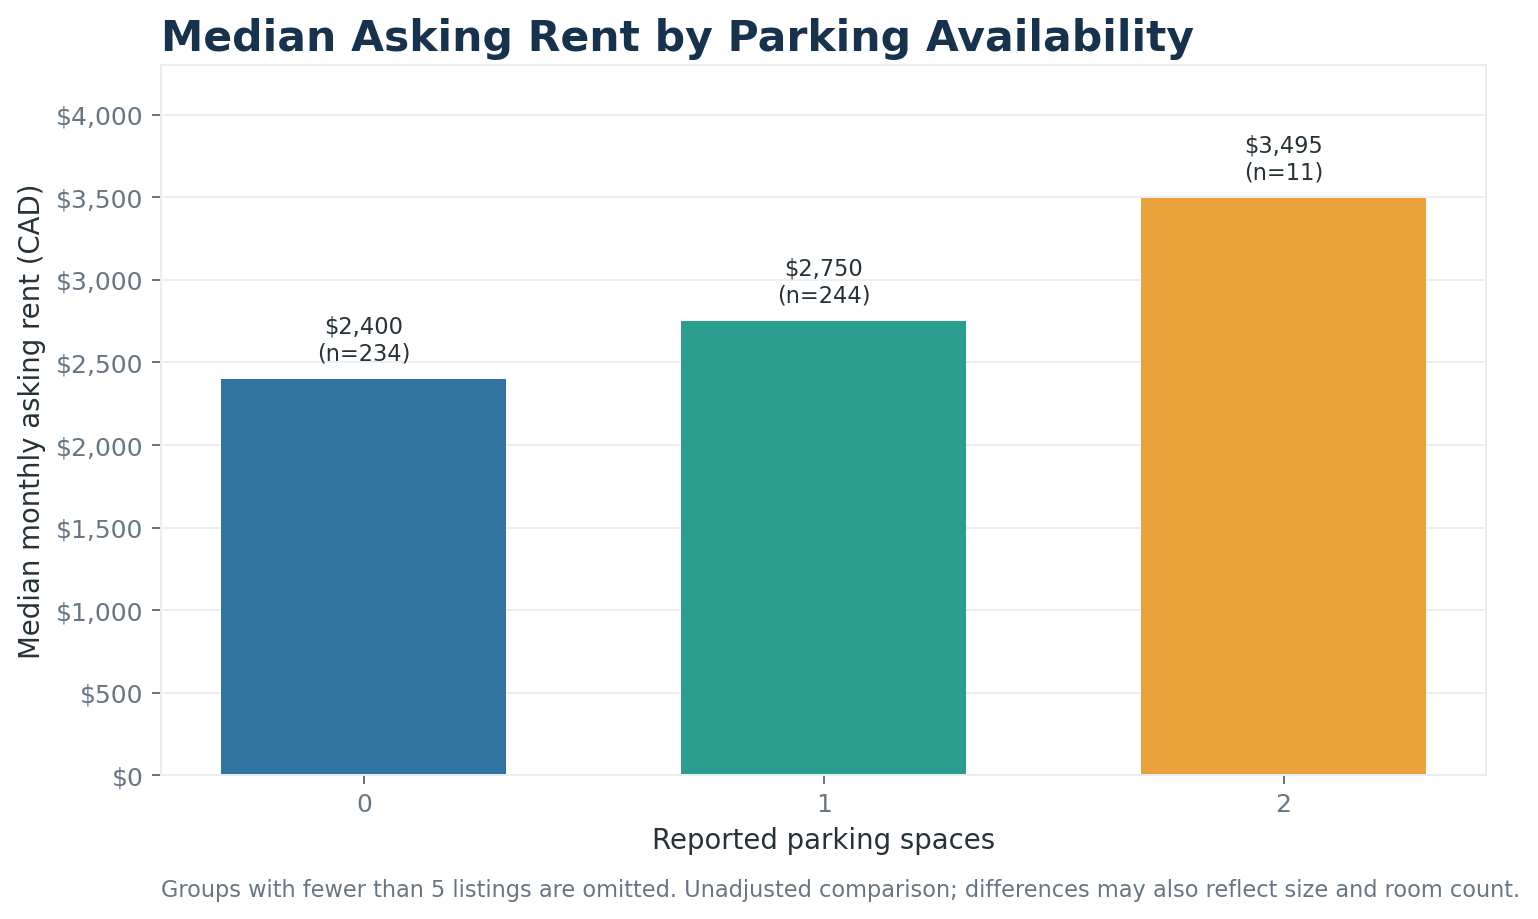

In [7]:
parking_display = parking_summary.loc[
    parking_summary["Listings"].ge(5),
    ["Parking", "Listings", "MedianRentCAD", "RentQ1CAD", "RentQ3CAD"],
].copy()
parking_display["Parking"] = parking_display["Parking"].astype(int)
parking_display.columns = [
    "Parking spaces", "Listings", "Median rent", "Q1 rent", "Q3 rent"
]
for column in ["Median rent", "Q1 rent", "Q3 rent"]:
    parking_display[column] = parking_display[column].map(
        lambda value: f"${value:,.0f}"
    )

display(parking_display)
display(Image(filename=CHART_DIR / "median_rent_by_parking.png"))

**Interpretation.** Listings reporting one space had a $2,750
median asking rent, $350 (14.6%) above listings reporting no parking. The
difference should not be treated as the causal value of parking: listings with
parking may also be larger, newer, or located in different submarkets.

## 6. Approximate size and asking rent

Listing pages report size bands rather than exact areas. For closed ranges, the
analysis uses the midpoint as an approximation. Open-ended bands are retained
in the broader rent analysis and omitted here.

Metric,Value,Scope
Listings with closed size ranges,407,Closed ranges only
Median approximate size,649.5 sqft,Range midpoint
Median asking rent per sqft,$3.91,Range midpoint denominator
Pearson correlation: size vs. rent,0.45,IQR price flags excluded


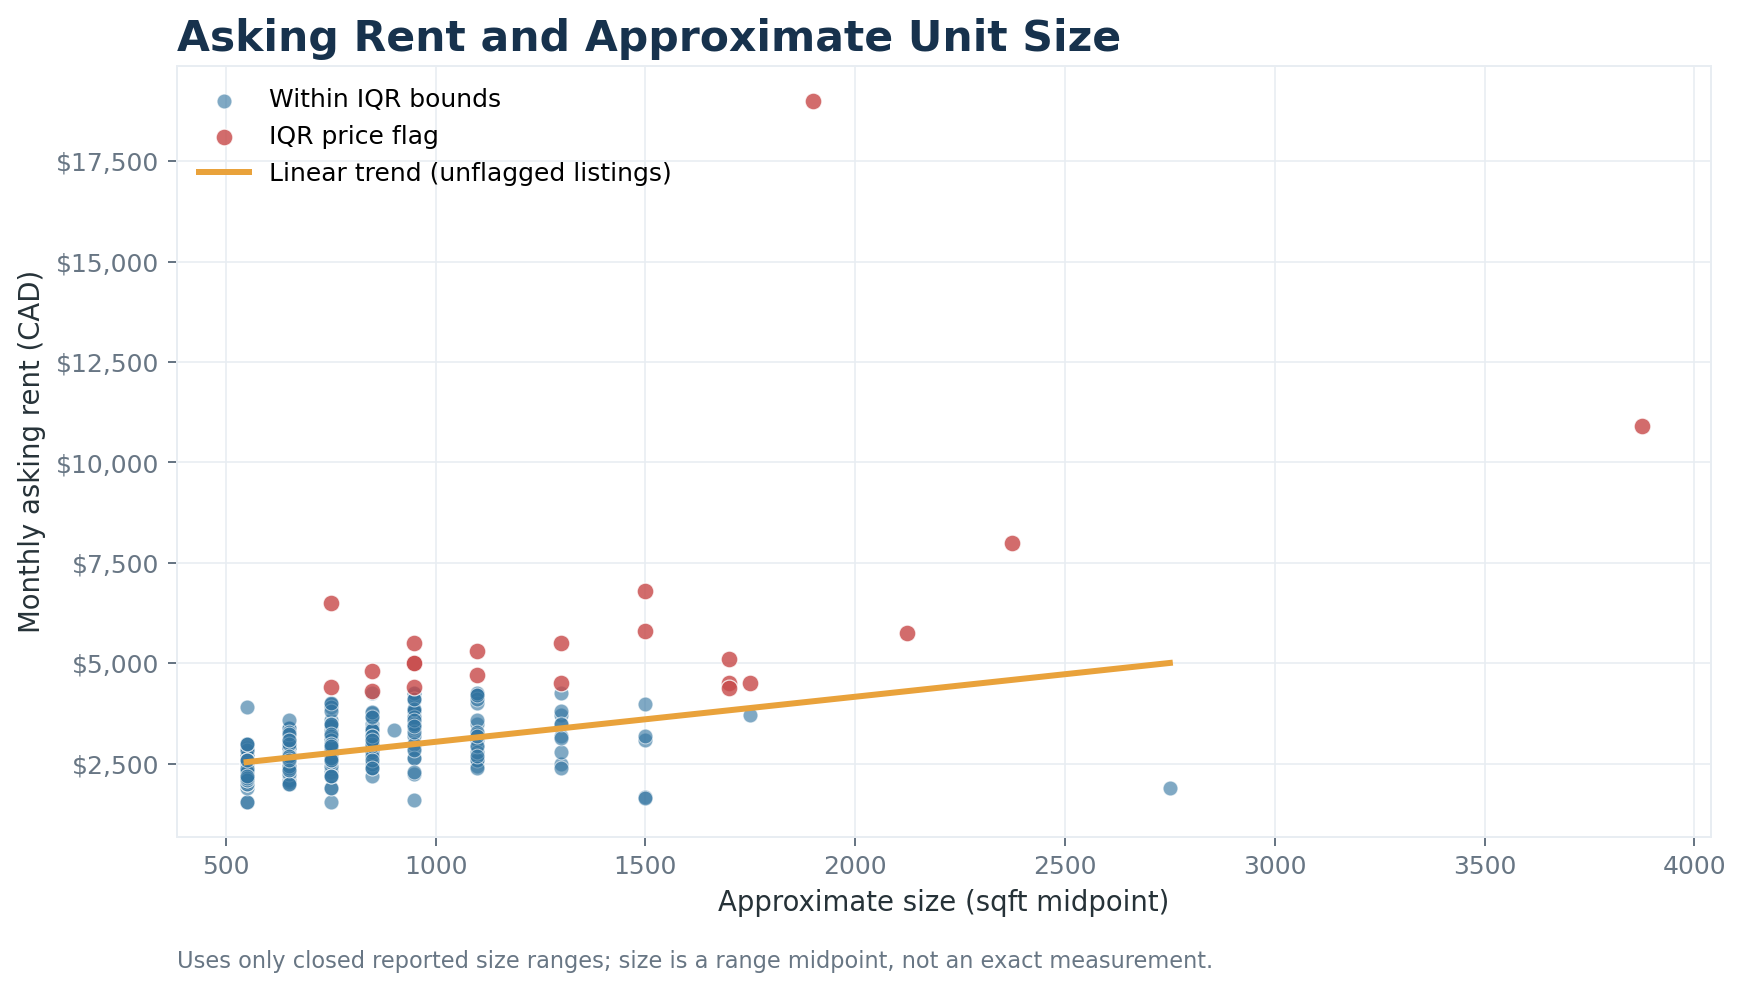

In [8]:
closed_size = df.dropna(
    subset=["AnalysisSizeSqft", "PriceCAD"]
).copy()
unflagged = closed_size.loc[~closed_size["PriceOutlierIQR"]]
size_rent_correlation = unflagged["AnalysisSizeSqft"].corr(
    unflagged["PriceCAD"]
)

size_summary = pd.DataFrame(
    {
        "Metric": [
            "Listings with closed size ranges",
            "Median approximate size",
            "Median asking rent per sqft",
            "Pearson correlation: size vs. rent",
        ],
        "Value": [
            f"{len(closed_size):,}",
            f"{closed_size['AnalysisSizeSqft'].median():,.1f} sqft",
            f"${closed_size['PricePerSqft'].median():,.2f}",
            f"{size_rent_correlation:.2f}",
        ],
        "Scope": [
            "Closed ranges only",
            "Range midpoint",
            "Range midpoint denominator",
            "IQR price flags excluded",
        ],
    }
)

display(size_summary)
display(Image(filename=CHART_DIR / "rent_vs_size.png"))

**Interpretation.** The positive relationship is meaningful but
not sufficient for valuation. The unflagged sample has a Pearson correlation
of 0.45 between approximate size and asking rent. A stronger model would add
neighbourhood, building, room configuration, amenities, and collection time.

## 7. Conclusions, limitations, and next steps

### Conclusions

- **Typical rent:** the sample median was $2,550 per month.
- **Room mix matters:** median asking rent increased materially across the
  major room configurations.
- **Parking is associated with higher listed rent:** the observed difference is
  useful descriptively but is not a causal estimate.
- **Size helps explain rent:** approximate size shows a moderate positive
  relationship with asking rent, while leaving substantial variation for other
  features to explain.

### Limitations

- This is a **10-page, single-time snapshot**, not a full market census.
- Values are **asking rents**, not signed lease prices.
- Size is a **reported range midpoint**, and 83 open-ended ranges are omitted
  from size-based metrics.
- Neighbourhood and building fields were not reliably available from every
  result card, so no geographic ranking is reported.
- Listings can change, expire, or be reposted after collection.

### Next steps

1. Enrich listings from detail pages only where source terms permit.
2. Add neighbourhood normalization and geospatial analysis.
3. Collect scheduled snapshots to measure inventory and rent changes over time.
4. Fit an interpretable multivariate rent model with held-out evaluation.
5. Add continuous integration for parser, cleaning, and analysis tests.

---

For the complete pipeline and command-line instructions, see the project
`README.md`. Generated CSV data is intentionally excluded from version control;
the validated charts and this executed notebook preserve the portfolio result.